In [113]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [114]:
from Base_Modules.Environments import Prison
from Prison_Strategies.Basic_Strategies import *
from Base_Modules.Game_Master import Game_Master
from Base_Modules.Action import Action_History, Prison_Actions, Duel_Matrix
import pandas as pd
from collections import defaultdict

In [115]:
prison = Prison()
actions = prison.Get_Actions()

In [116]:
strategies_list = [
    Random_Strategy(actions=actions),
    Random_Strategy(actions=actions, p_coop=0.1),
    Always_Betray(actions=actions),
    Always_Cooperate(actions=actions),
    Patient_Unforgiving(actions=actions),
    Copycat(actions=actions),
    Periodic(actions=actions, period=1),
]

number_of_strategies = len(strategies_list)

In [159]:
def Get_Index_By_Name(strategies : dict[int, Strategy], name : str) -> int:
    for ix, (id, s) in enumerate(strategies.items()):
        if str(s) == name:
            return id
    for ix, (id, s) in enumerate(strategies.items()):
        if  "".join(str(s).split(":")[1:]).startswith(name):
            return id
    for ix, (id, s) in enumerate(strategies.items()):
        if str(s).startswith(name):
            return id
    return -1

In [118]:
strategies = {}

for (i, s) in enumerate(strategies_list):
    strategies[i] = s
    s.Set_ID(i)

In [119]:
number_of_games = 1000
total_games_explicit = True
max_action_memory = -1

gm = Game_Master(prison, strategies=strategies, duel_size=2, max_action_memory=max_action_memory)
duel_matrix, rewards = gm.Tournament(number_of_games, Game_Master.Game_Type.All_Vs_All, total_games_explicit=total_games_explicit)
rewards.Sort_Total_Rewards()

## Analiza


In [120]:
def Sort_Based_On_Total_Rewards(total_rewards, data):
    sorted_data = dict(sorted(
        data.items(),
        key=lambda kv: total_rewards.get(kv[0], 0),
        reverse=True
    ))
    return sorted_data

In [121]:
total_rewards = rewards.Get_Total_Rewards()
total_rewards_per_name = {str(strategies[i]):total_rewards[i] for i in total_rewards.keys()}

average_rewards_per_match = {k: (float(v)/number_of_strategies) for k, v in total_rewards.items()}
average_rewards_per_round = {k: (float(v)/(number_of_strategies*number_of_games)) for k, v in total_rewards.items()}

duel_rewards = rewards.Get_All_Duel_Rewards()

duel_rewards = dict(sorted(duel_rewards.items(), key=lambda kv: total_rewards.get(kv[0][0]), reverse=True))

In [122]:
largest_shared_victory = -float("inf")
least_shared_victory = float("inf")

for (_, rewards) in duel_rewards.items():
    largest_shared_victory = max(largest_shared_victory, sum(rewards.values()))
    least_shared_victory = min(least_shared_victory, sum(rewards.values()))


print(f"Largest shared reward: {largest_shared_victory}")
print(f"Least shared reward: {least_shared_victory}")


Largest shared reward: 6000
Least shared reward: 2003


In [123]:
from Base_Modules.Nemesis import Nemesis_Best_Enemy_Score, Nemesis_Worst_Score, Nemesis_Largest_Difference

criterion = Nemesis_Worst_Score

nemesis = criterion.Get_Nemesis(duel_rewards=duel_rewards)
nemesis = Sort_Based_On_Total_Rewards(total_rewards=total_rewards, data=nemesis)
nemesis_per_name = criterion.Translate_Nemesis_To_Strategy_Names(strategies=strategies, nemesis=nemesis)

nemesis_df = pd.DataFrame(
    [(k, v[0]) for k, v in nemesis_per_name.items()],
    columns=["Strategy", "Its nemesis"]
)

In [124]:
from Base_Modules.Nemesis import Friend_Best_Total_Score, Friend_Best_Own_Score

criterion = Friend_Best_Own_Score

friends = criterion.Get_Nemesis(duel_rewards=duel_rewards)
friends = Sort_Based_On_Total_Rewards(total_rewards=total_rewards, data=friends)
friends_per_name = criterion.Translate_Nemesis_To_Strategy_Names(strategies=strategies, nemesis=friends)

friends_df = pd.DataFrame(
    [(k, v[0]) for k, v in friends_per_name.items()],
    columns=["Strategy", "Its friend"]
)

## Dataframes

In [125]:
average_reward_per_round_df = pd.DataFrame.from_dict(average_rewards_per_round, orient="index", columns=["Average Reward"])
average_reward_per_round_df.index.name = "Strategy Name"
average_reward_per_round_df = average_reward_per_round_df.round(3)

In [126]:
# Per match

average_reward_per_match_df = pd.DataFrame.from_dict(average_rewards_per_match, orient="index", columns=["Average Reward"])
average_reward_per_match_df.index.name = "Strategy Name"
average_reward_per_match_df = average_reward_per_match_df.round(3)

In [127]:
strat_names = [str(strategies[s]) for s in total_rewards.keys()]

score_matrix = pd.DataFrame(index=strat_names, columns=strat_names, dtype=object)

for (s1, s2), scores in duel_rewards.items():
    score_matrix.loc[str(strategies[s2]), str(strategies[s1])] = (scores[s2], scores[s1])
    score_matrix.loc[str(strategies[s1]), str(strategies[s2])] = (scores[s1], scores[s2])

for s in strat_names:
    score_matrix.loc[s, s] = (0, 0)

In [128]:
sum_matrix = pd.DataFrame(index=strat_names, columns=strat_names, dtype=object)

for (s1, s2), scores in duel_rewards.items():
    sum_matrix.loc[str(strategies[s2]), str(strategies[s1])] = (scores[s2] + scores[s1])
    sum_matrix.loc[str(strategies[s1]), str(strategies[s2])] = (scores[s2] + scores[s1])

for s in strat_names:
    sum_matrix.loc[s, s] = 0

In [129]:
victory_matrix = score_matrix.apply(lambda col: col.map(lambda x: int(x[0] > x[1])))
for s in strat_names:
    victory_matrix.loc[s, s] = float("NaN")

In [130]:
def color_cell(x):
    if not isinstance(x, tuple):
        return ""
    if x[0] == 0 and x[1] == 0:
        return "background-color: black"
    elif x[0] > x[1]:
        return "background-color: green"
    elif x[0] < x[1]:
        return "background-color: darkred"
    else:
        return "background-color: gray"

styled_score_matrix = (
    score_matrix.style
    .map(color_cell)
    .set_properties(**{
        "border": "1px solid black"
    })
    .set_table_styles([
        {"selector": "th", "props": [("border", "2px solid black")]},
        {"selector": "td", "props": [("border", "2px solid black")]}
    ])
)

display(styled_score_matrix)

,(2):Always_Betray,(4):Patient_Unforgiving (patience=1),(1):Random_Strategy (p_coop=0.1),(5):Copycat (1st=Cooperate),(6):Periodic (period=1),(0):Random_Strategy (p_coop=0.5),(3):Always_Cooperate
(2):Always_Betray,"(0, 0)","(1004, 999)","(1412, 897)","(1004, 999)","(3000, 500)","(2900, 525)","(5000, 0)"
(4):Patient_Unforgiving (patience=1),"(999, 1004)","(0, 0)","(1379, 909)","(3000, 3000)","(2997, 507)","(2941, 526)","(3000, 3000)"
(1):Random_Strategy (p_coop=0.1),"(897, 1412)","(909, 1379)","(0, 0)","(1283, 1278)","(2820, 900)","(2939, 849)","(4788, 318)"
(5):Copycat (1st=Cooperate),"(999, 1004)","(3000, 3000)","(1278, 1283)","(0, 0)","(2498, 2503)","(2191, 2196)","(3000, 3000)"
(6):Periodic (period=1),"(500, 3000)","(507, 2997)","(900, 2820)","(2503, 2498)","(0, 0)","(2201, 2266)","(4000, 1500)"
(0):Random_Strategy (p_coop=0.5),"(525, 2900)","(526, 2941)","(849, 2939)","(2196, 2191)","(2266, 2201)","(0, 0)","(3990, 1515)"
(3):Always_Cooperate,"(0, 5000)","(3000, 3000)","(318, 4788)","(3000, 3000)","(1500, 4000)","(1515, 3990)","(0, 0)"


In [131]:
import webbrowser
store_styled_matrix_in_html = False
if store_styled_matrix_in_html:
    styled_score_matrix.to_html("styled_score_matrix.html")
    webbrowser.open_new_tab("styled_score_matrix.html")

## Wyniki

In [132]:
def get_name(id : int) -> str:
    return "".join(str(strategies[id]).split(":")[1:])

summary = {}
for ix, (id, score) in enumerate(total_rewards.items()):
    summary[ix] = {"Name": get_name(id),
                   "Average score": average_rewards_per_round[id],
                   "Nemesis": get_name(nemesis[id][0]),
                   "Friend": get_name(friends[id][0])}

summary_df = pd.DataFrame.from_dict(summary, orient="index")
summary_df.index.name = "Place"

display(summary_df.round(2))

,Name,Average score,Nemesis,Friend
Place,,,,
0,Always_Betray,2.05,Patient_Unforgiving (patience=1),Always_Cooperate
1,Patient_Unforgiving (patience=1),2.05,Always_Betray,Copycat (1st=Cooperate)
2,Random_Strategy (p_coop=0.1),1.95,Always_Betray,Always_Cooperate
3,Copycat (1st=Cooperate),1.85,Always_Betray,Patient_Unforgiving (patience=1)
4,Periodic (period=1),1.52,Always_Betray,Always_Cooperate
5,Random_Strategy (p_coop=0.5),1.48,Always_Betray,Always_Cooperate
6,Always_Cooperate,1.33,Always_Betray,Patient_Unforgiving (patience=1)


0
5


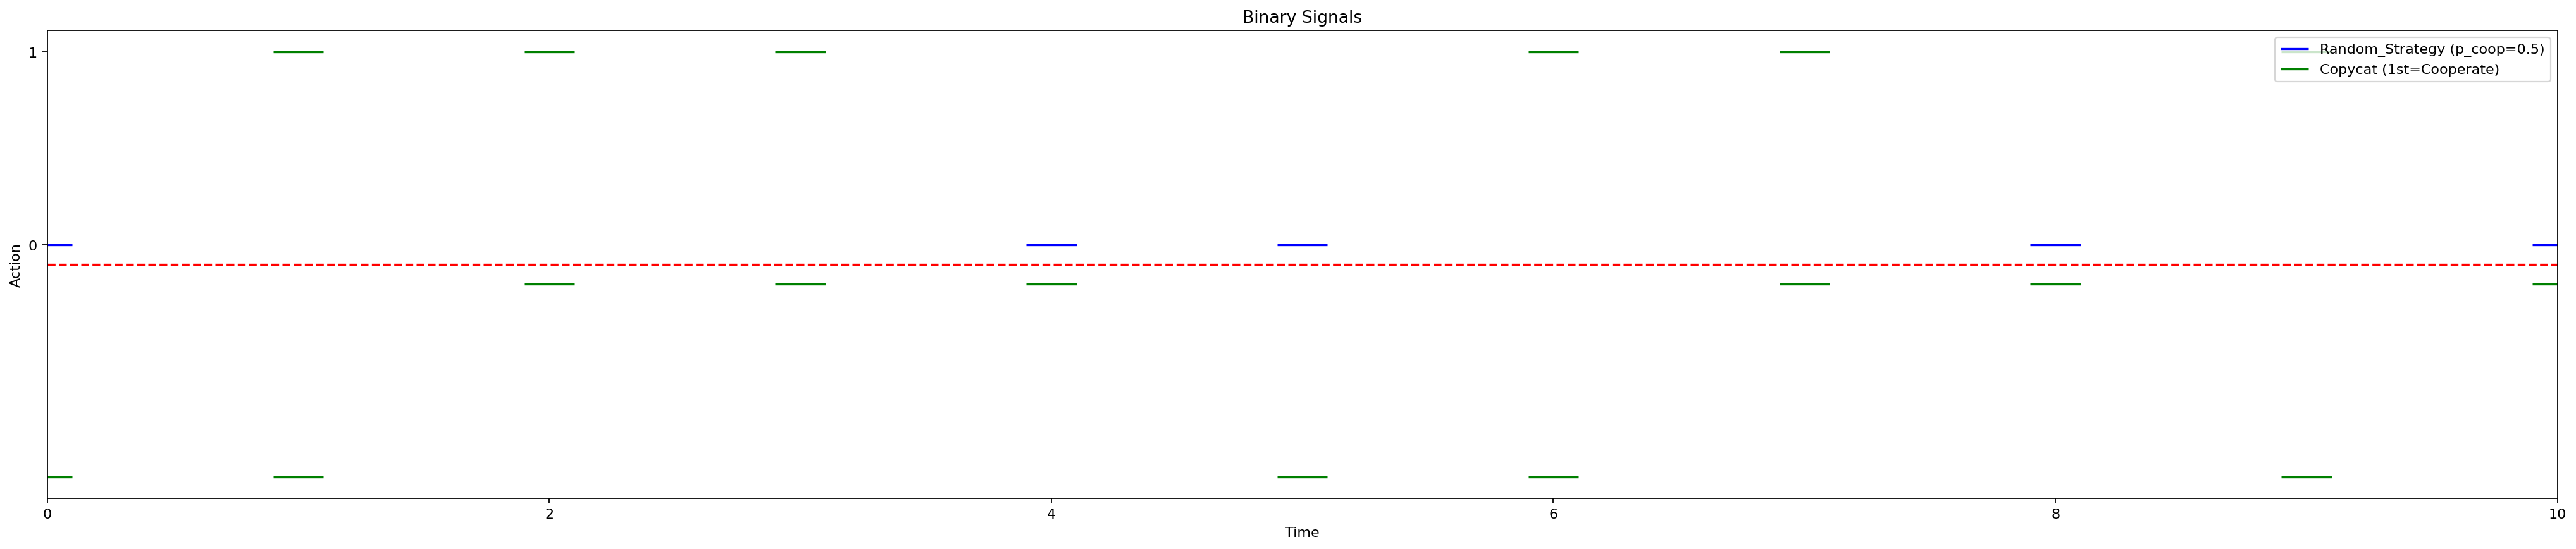

In [171]:
import matplotlib.pyplot as plt
%matplotlib inline

x_min = 0
x_max = 10
strategy1_name = "Random"
strategy2_name = "Copycat"

strategy1_ID = Get_Index_By_Name(strategies=strategies, name=strategy1_name)
strategy2_ID = Get_Index_By_Name(strategies=strategies, name=strategy2_name)

print(strategy1_ID)
print(strategy2_ID)

data = duel_matrix.Get_Action_History((strategy1_ID, strategy2_ID)).Get_Action_History()

plt.figure(figsize=(32, 6), dpi=160)

for i, (key, values) in enumerate(data.items()):
    y = [v.value - 1.2*i for v in values]
    x = list(range(len(y)))

    # step plot for binary signal
    # plt.step(x, y, where='post', label=f"Signal {key}")
    # plt.scatter(x, y, label=f"Signal {key}")
    for i, val in enumerate(y):
        color = "b" if val == 0 else "g"
        plt.hlines(val, float(float(i)-0.1), float(float(i)+0.1), colors=[color])

plt.hlines(y = -0.1, xmin=x_min, xmax=x_max, colors=["r"], linestyles="--")
plt.xlim([0, 10])
plt.yticks([0, 1])
plt.xlabel("Time")
plt.ylabel("Action")
plt.title("Binary Signals")
plt.legend([get_name(strategy1_ID), get_name(strategy2_ID)])
# plt.grid(True)

plt.show()